<a href="https://colab.research.google.com/github/frank-morales2020/AST/blob/main/HF_TO_Github.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Github MIGRATION

In [ ]:
from google.colab import userdata
from huggingface_hub import HfApi, snapshot_download
import os
import shutil
import subprocess
import requests

GH_PAT = userdata.get('GH_PAT')
username = 'frankmorales2020'

print(GH_PAT)

In [ ]:
from google.colab import userdata
from huggingface_hub import snapshot_download
import os
import shutil
import subprocess

from warnings import filterwarnings
filterwarnings('ignore')

# 1. Setup credentials from Colab Secrets
HF_TOKEN = userdata.get('HF_TOKEN')
GH_PAT = userdata.get('GH_PAT')
username = 'frankmorales2020'

#MODEL_ID = "frankmorales2020/topo-gemma-4-e4b-vision-13tasks"
#repo_id: str = "frankmorales2020/topo-gemma-4-e4b-vision-13tasks",
#base_model: str = "frankmorales2020/gemma-4-e4b-unesco-optimized",

# 2. Define the explicit list of models to copy
target_models = [
   "frankmorales2020/topo-gemma-4-e4b-vision-13tasks",
]

local_repo_dir = "./TOPO_REPO"
if os.path.exists(local_repo_dir):
    shutil.rmtree(local_repo_dir)

# 3. Clone existing TOPO repository or initialize if empty
repo_url_auth = f"https://{GH_PAT}@github.com/{username}/TOPO.git"
print("Cloning your frank-morales2020/TOPO repository...")

print(target_models)

try:
    subprocess.run(["git", "clone", repo_url_auth, local_repo_dir], check=True)
    print("  Successfully cloned repository!")
except subprocess.CalledProcessError:
    os.makedirs(local_repo_dir, exist_ok=True)
    subprocess.run(["git", "init"], cwd=local_repo_dir, check=True)
    subprocess.run(["git", "config", "user.name", username], cwd=local_repo_dir, check=True)
    subprocess.run(["git", "config", "user.email", "frank@somala.ai"], cwd=local_repo_dir, check=True)
    subprocess.run(["git", "remote", "add", "origin", repo_url_auth], cwd=local_repo_dir, check=True)
    subprocess.run(["git", "pull", "origin", "main", "--allow-unrelated-histories"], cwd=local_repo_dir, check=False)


models_dir = os.path.join(local_repo_dir, "models")
os.makedirs(models_dir, exist_ok=True)

print(f"\nProcessing {len(target_models)} selected models...\n")

success_count = 0

for idx, model_id in enumerate(target_models, 1):
    model_name = model_id.split('/')[-1]
    target_path = os.path.join(models_dir, model_name)

    print(f"[{idx}/{len(target_models)}] Downloading {model_name}...")
    os.makedirs(target_path, exist_ok=True)

    try:
        # Download model snapshot directly into the repo folder
        snapshot_download(
            repo_id=model_id,
            local_dir=target_path,
            token=HF_TOKEN
        )

        print(f"  Successfully staged and committed {model_name}")
        success_count += 1
    except Exception as e:
        print(f"  Error processing {model_id}: {e}")

print("\n" + "="*50)
print(f"Migration Prep Complete! Successfully processed {success_count}/{len(target_models)} models.")
print("Pushing models to GitHub...")
print("="*50)

Cloning your frank-morales2020/TOPO repository...
['frankmorales2020/topo-gemma-4-e4b-vision-13tasks']

Processing 1 selected models...

[1/1] Downloading topo-gemma-4-e4b-vision-13tasks...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

  Successfully staged and committed topo-gemma-4-e4b-vision-13tasks

Migration Prep Complete! Successfully processed 1/1 models.
Pushing models to GitHub...


In [ ]:
!ls -ltha /content/TOPO_REPO/models/topo-gemma-4-e4b-vision-13tasks | wc -l

11


In [ ]:
!ls -ltha /content/TOPO_REPO/models/topo-gemma-4-e4b-vision-13tasks

total 2.6G
drwxr-xr-x 3 root root 4.0K Sep 16 07:19 .
-rw-r--r-- 1 root root 2.6G Sep 16 07:19 pytorch_model.bin
-rw-r--r-- 1 root root  31M Sep 16 07:19 tokenizer.json
-rw-r--r-- 1 root root  26K Sep 16 07:19 README.md
-rw-r--r-- 1 root root  525 Sep 16 07:19 config.json
-rw-r--r-- 1 root root 2.8K Sep 16 07:19 tokenizer_config.json
-rw-r--r-- 1 root root  184 Sep 16 07:19 .gitattributes
-rw-r--r-- 1 root root  12K Sep 16 07:19 chat_template.jinja
drwxr-xr-x 3 root root 4.0K Sep 16 07:19 .cache
drwxr-xr-x 3 root root 4.0K Sep 16 07:19 ..


In [ ]:
import subprocess
import os

local_repo_dir = "./TOPO_REPO"
model_dir = os.path.join(local_repo_dir, "models/topo-gemma-4-e4b-vision-13tasks")
model_path = os.path.join(model_dir, "pytorch_model.bin")

if not os.path.exists(model_path):
    print(f"Error: Source file not found at {model_path}.")
    print("Please make sure the full 'pytorch_model.bin' file is placed in that directory before running the split script.")
else:
    print("Splitting large file...")
    subprocess.run(
        ["split", "-b", "50M", model_path, f"{model_path}.part"],
        check=True
    )

    print("Removing original file...")
    os.remove(model_path)

    # Force binary tracking without LFS for the split parts
    gitattributes_path = os.path.join(model_dir, ".gitattributes")
    with open(gitattributes_path, "w") as f:
        f.write("pytorch_model.bin.part* -lfs\n")

    print("Adding split files to git (with LFS bypassed)...")
    subprocess.run(["git", "add", "-A"], cwd=local_repo_dir, check=True)
    subprocess.run(
        ["git", "commit", "-m", "Split pytorch_model.bin and bypass LFS for parts"],
        cwd=local_repo_dir,
        check=True,
        capture_output=True
    )

    print("Ready to push raw parts to GitHub!")

Splitting large file...
Removing original file...
Adding split files to git (with LFS bypassed)...
Ready to push raw parts to GitHub!


In [ ]:
!ls -ltha /content/TOPO_REPO/models/topo-gemma-4-e4b-vision-13tasks/* | wc -l

57


In [ ]:
!ls -ltha /content/TOPO_REPO/models/topo-gemma-4-e4b-vision-13tasks

reconstruction-test

In [ ]:
import glob
import os

base_dir = "./TOPO_REPO/models/topo-gemma-4-e4b-vision-13tasks"
output_file = os.path.join(base_dir, "pytorch_model.bin")

# Get all parts sorted alphabetically (partaa, partab, ..., partbz)
part_files = sorted(glob.glob(os.path.join(base_dir, "pytorch_model.bin.part*")))

print(f"Combining {len(part_files)} parts into {output_file}...")

with open(output_file, "wb") as outfile:
    for part in part_files:
        with open(part, "rb") as infile:
            outfile.write(infile.read())

print(f"Done! Final file size: {os.path.getsize(output_file) / (1024**3):.2f} GB")

Combining 52 parts into ./TOPO_REPO/models/topo-gemma-4-e4b-vision-13tasks/pytorch_model.bin...
Done! Final file size: 2.50 GB


In [ ]:
!rm -rf /content/TOPO_REPO/models/topo-gemma-4-e4b-vision-13tasks/pytorch_model.bin

In [ ]:
import requests
from google.colab import userdata

GH_PAT = userdata.get('GH_PAT')
repo_owner = "frank-morales2020"
repo_name = "TOPO"

headers = {
    "Authorization": f"Bearer {GH_PAT}",
    "Accept": "application/vnd.github+json"
}

url = f"https://api.github.com/repos/{repo_owner}/{repo_name}"

response = requests.delete(url, headers=headers)

if response.status_code == 204:
    print(f"✓ Successfully deleted repository {repo_owner}/{repo_name}")
else:
    print(f"✗ Failed to delete repository: {response.status_code}")
    print(response.json())

✓ Successfully deleted repository frank-morales2020/TOPO


In [ ]:
import os
import subprocess
import requests
from google.colab import userdata
from tqdm import tqdm

local_repo_dir = "./TOPO_REPO"
GH_PAT = userdata.get('GH_PAT')
repo_owner = "frank-morales2020"
repo_name = "TOPO"

headers = {
    "Authorization": f"token {GH_PAT}",
    "Accept": "application/vnd.github+json"
}

env = {**os.environ, "GIT_TERMINAL_PROMPT": "0"}

# Clean stale locks
lock_file = os.path.join(local_repo_dir, ".git", "index.lock")
if os.path.exists(lock_file):
    os.remove(lock_file)

# 1. Ensure repository exists and is public
print("-> Checking repository status...")
check_res = requests.get(f"https://api.github.com/repos/{repo_owner}/{repo_name}", headers=headers)
if check_res.status_code == 404:
    print("-> Creating public repository...")
    create_res = requests.post(
        "https://api.github.com/user/repos",
        headers=headers,
        json={"name": repo_name, "private": False}
    )
    if create_res.status_code not in (201, 200):
        print(f"ERROR: {create_res.text}")
        raise RuntimeError("Repo creation failed")
else:
    print("-> Repository exists")

# 2. Configure Git remote and settings (LFS removed entirely to prevent pointer issues)
print("-> Configuring Git settings...")
subprocess.run(["git", "remote", "remove", "origin"], cwd=local_repo_dir, capture_output=True, env=env)
subprocess.run([
    "git", "remote", "add", "origin",
    f"https://{GH_PAT}@github.com/{repo_owner}/{repo_name}.git"
], cwd=local_repo_dir, check=True, env=env)
subprocess.run(["git", "config", "user.email", "bot@example.com"], cwd=local_repo_dir, check=True)
subprocess.run(["git", "config", "user.name", "Bot"], cwd=local_repo_dir, check=True)
subprocess.run(["git", "branch", "-M", "main"], cwd=local_repo_dir, check=True)
subprocess.run(["git", "config", "http.postBuffer", "2147483648"], cwd=local_repo_dir, check=True)

# 3. Gather files, excluding caches (keeping .gitattributes so LFS stays bypassed)
all_files = []
for root, dirs, files in os.walk(local_repo_dir):
    if ".git" in root or ".cache" in root:
        continue
    for file in files:
        if file.startswith("."):
            if file != ".gitattributes":
                continue
        rel_path = os.path.relpath(os.path.join(root, file), local_repo_dir)
        all_files.append(rel_path)

# 4. Add files
print(f"-> Staging {len(all_files)} files...")
for f in tqdm(all_files, desc="Staging"):
    subprocess.run(["git", "add", f], cwd=local_repo_dir, check=True, env=env)

# 5. Check if there are changes to commit
diff_check = subprocess.run(["git", "diff", "--cached", "--quiet"], cwd=local_repo_dir, env=env)
if diff_check.returncode != 0:
    print("-> Committing...")
    subprocess.run(["git", "commit", "-m", "Add raw split model parts without LFS"], cwd=local_repo_dir, check=True, env=env)
else:
    print("-> No changes to commit")

# 6. Push to GitHub
print("-> Pushing to GitHub...")
subprocess.run(["git", "push", "-u", "origin", "main"], cwd=local_repo_dir, check=True, env=env)

print(f"\n✓ DONE: https://github.com/{repo_owner}/{repo_name}")

-> Checking repository status...
-> Creating public repository...
-> Configuring Git settings...
-> Staging 58 files...




Staging:   0%|          | 0/58 [00:00<?, ?it/s]

Staging: 100%|██████████| 58/58 [00:00<00:00, 566.07it/s]

-> No changes to commit
-> Pushing to GitHub...



✓ DONE: https://github.com/frank-morales2020/TOPO


In [ ]:
import subprocess

local_repo_dir = "./TOPO_REPO"

print("-> Pushing to GitHub...")
result = subprocess.run(
    ["git", "push", "-u", "origin", "main"],
    cwd=local_repo_dir,
    capture_output=True,
    text=True
)

print("STDOUT:")
print(result.stdout)
print("\nSTDERR:")
print(result.stderr)

print(f"\n✓ DONE: https://github.com/{repo_owner}/{repo_name}")

## INFERENCE

https://github.com/frank-morales2020/TOPO

In [ ]:
!pip install unsloth -q

In [ ]:
import torch
import os
import sys
import contextlib
from PIL import Image
from unsloth import FastVisionModel
import subprocess

# Suppress all output during imports
@contextlib.contextmanager
def suppress_all_output():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

os.environ["UNSLOTH_DISABLE_LOGGING"] = "1"
os.environ["TQDM_DISABLE"] = "1"

# 1. Clone model from GitHub
print("Cloning model from GitHub...")
subprocess.run(["git", "clone", "https://github.com/frank-morales2020/TOPO.git"],
               capture_output=True)

model_dir = "./TOPO/models/topo-gemma-4-e4b-vision-13tasks"

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Cloning model from GitHub...


In [ ]:
!ls -ltha /content/TOPO/models/topo-gemma-4-e4b-vision-13tasks

In [ ]:
import os
import urllib.request

base_dir = "/content/TOPO/models/topo-gemma-4-e4b-vision-13tasks"
os.makedirs(base_dir, exist_ok=True)
output_file = os.path.join(base_dir, "pytorch_model.bin")

# Generate suffix letters like aa, ab, ac ... bz
suffixes = []
for first in range(ord('a'), ord('z') + 1):
    for second in range(ord('a'), ord('z') + 1):
        suffixes.append(chr(first) + chr(second))

# We know there are 52 parts (aa through bz or similar)
target_suffixes = suffixes[:52]

print("Downloading raw split parts directly from GitHub...")

if os.path.exists(output_file):
    os.remove(output_file)

with open(output_file, "wb") as outfile:
    for suffix in target_suffixes:
        filename = f"pytorch_model.bin.part{suffix}"
        url = f"https://raw.githubusercontent.com/frank-morales2020/TOPO/main/models/topo-gemma-4-e4b-vision-13tasks/{filename}"

        print(f"Fetching {filename}...")
        try:
            with urllib.request.urlopen(url) as response:
                chunk = response.read()
                outfile.write(chunk)
                print(f" -> Appended {len(chunk)} bytes")
        except Exception as e:
            print(f" -> Failed to download {filename}: {e}")

print(f"\nMerging complete! Final file size: {os.path.getsize(output_file) / (1024**3):.2f} GB")

In [ ]:
!rm -rf /content/TOPO/models/topo-gemma-4-e4b-vision-13tasks/*pytorch_model.bin.part*

In [ ]:
!ls -ltha /content/TOPO/models/topo-gemma-4-e4b-vision-13tasks/pytorch_model.bin.part*

ls: cannot access '/content/TOPO/models/topo-gemma-4-e4b-vision-13tasks/pytorch_model.bin.part*': No such file or directory


In [ ]:
!ls -ltha /content/TOPO/models/topo-gemma-4-e4b-vision-13tasks/pytorch_model.bin

-rw-r--r-- 1 root root 2.6G Sep 16 16:34 /content/TOPO/models/topo-gemma-4-e4b-vision-13tasks/pytorch_model.bin


In [ ]:
!ls -ltha /content/TOPO/models/topo-gemma-4-e4b-vision-13tasks

total 2.6G
drwxr-xr-x 2 root root 4.0K Sep 16 16:38 .
-rw-r--r-- 1 root root 2.6G Sep 16 16:34 pytorch_model.bin
-rw-r--r-- 1 root root 2.8K Sep 16 16:30 tokenizer_config.json
-rw-r--r-- 1 root root  31M Sep 16 16:30 tokenizer.json
drwxr-xr-x 3 root root 4.0K Sep 16 16:30 ..
-rw-r--r-- 1 root root  12K Sep 16 16:30 chat_template.jinja
-rw-r--r-- 1 root root  525 Sep 16 16:30 config.json
-rw-r--r-- 1 root root   29 Sep 16 16:30 .gitattributes
-rw-r--r-- 1 root root  26K Sep 16 16:30 README.md


In [ ]:
import torch
import os
import sys
import contextlib
from PIL import Image
from unsloth import FastVisionModel
import subprocess

@contextlib.contextmanager
def suppress_all_output():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

os.environ["UNSLOTH_DISABLE_LOGGING"] = "1"
os.environ["TQDM_DISABLE"] = "1"


model_dir = "./TOPO/models/topo-gemma-4-e4b-vision-13tasks"
ckpt_path = os.path.join(model_dir, "pytorch_model.bin")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Loading 0-forgetting model...
Using base model: frankmorales2020/gemma-4-e4b-unesco-optimized


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

✓ 0-Forgetting model loaded


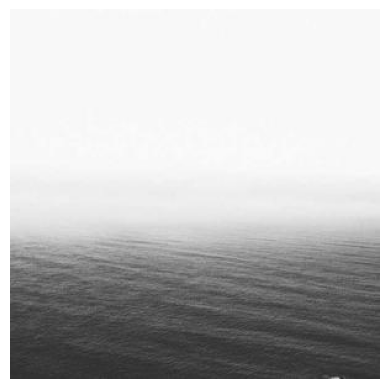


🚀 EVALUATING ALL 13 TOPO-2026 TASKS (0-FORGETTING)

[Task A] Animal vs Vehicle              ➔ This image does not depict an animal or a vehicle. It is a photograph of a **sea or ocean horizon** with a vast, misty sky.
[Task B] Natural vs Man-Made            ➔ This subject is **natural**.

It depicts a vast expanse of **ocean or sea** under a **sky**, which are natural elements.
[Task C] Living vs Non-Living           ➔ The primary subject in the image is the **sea/ocean**.

Therefore, the primary subject is **non-living**.
[Task D] Large vs Small                 ➔ Based on the image, the subject is the **ocean/sea**.

In terms of scale, the ocean is **very large** in scale. The image depicts a vast expanse of water meeting a vast, foggy sky, suggesting an immense, expansive subject.
[Task E] Ground vs Air/Water            ➔ This subject belongs to **air/water**.

The image primarily features a vast expanse of water meeting the sky, which falls under the category of air/water.
[Task F]

In [ ]:
# 4. Load model
print("Loading 0-forgetting model...")
checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)
BASE_MODEL = checkpoint.get("base_model", "frankmorales2020/gemma-4-e4b-unesco-optimized")

print(f"Using base model: {BASE_MODEL}")

with suppress_all_output():
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name=BASE_MODEL,
        load_in_4bit=True,
        dtype=torch.bfloat16,
    )
    model.load_state_dict(checkpoint, strict=False)
    FastVisionModel.for_inference(model)

print("✓ 0-Forgetting model loaded")

# 5. Download test image
print("Downloading test image...")
os.system("wget -q -O test_image.jpg https://picsum.photos/300/300")
image = Image.open("test_image.jpg").convert("RGB")

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("test_image.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

# 6. Define all 13 tasks
tasks0 = [
    ("Task A", "Animal vs Vehicle", "Does this image depict an animal or a vehicle?"),
    ("Task B", "Natural vs Man-Made", "Is this subject natural or man-made?"),
    ("Task C", "Living vs Non-Living", "Is the primary subject living or non-living?"),
    ("Task D", "Large vs Small", "Is the subject large or small in scale?"),
    ("Task E", "Ground vs Air/Water", "Does this subject belong to ground or air/water?"),
    ("Task F", "Domestic vs Wild", "Is this subject domestic or wild?"),
    ("Task G", "Mammal vs Non-Mammal", "Is this subject a mammal or non-mammal?"),
    ("Task H", "Flying vs Non-Flying", "Is this subject flying or non-flying?"),
    ("Task I", "Fast vs Slow", "Is this subject characterized as fast or slow?"),
    ("Task J", "Urban vs Rural", "Does this setting represent an urban or rural environment?"),
    ("Task K", "Predator vs Prey", "Is this subject a predator or prey?"),
    ("Task L", "Nocturnal vs Diurnal", "Is this subject nocturnal or diurnal?"),
    ("Task M", "Domesticated vs Wild Animals", "Is this animal domesticated or wild?")
]

tasks = [
    ("Task A", "Animal vs Vehicle", "Does this image depict an animal or a vehicle?"),
    ("Task B", "Natural vs Man-Made", "Is this subject natural or man-made?"),
    ("Task C", "Living vs Non-Living", "Is the primary subject living or non-living?"),
    ("Task D", "Large vs Small", "Is the subject large or small in scale?"),
    ("Task E", "Ground vs Air/Water", "Does this subject belong to ground or air/water?"),
    ("Task F", "Domestic vs Wild", "If applicable, is this subject domestic or wild? (State N/A if not an eligible entity)"),
    ("Task G", "Mammal vs Non-Mammal", "If this subject is an animal, is it a mammal or non-mammal? (State N/A if not an animal)"),
    ("Task H", "Flying vs Non-Flying", "If applicable, is this subject flying or non-flying? (State N/A if not applicable)"),
    ("Task I", "Fast vs Slow", "If applicable, is this subject characterized as fast or slow? (State N/A if static or inanimate)"),
    ("Task J", "Urban vs Rural", "Does this setting represent an urban or rural environment?"),
    ("Task K", "Predator vs Prey", "If this subject is an animal, is it a predator or prey? (State N/A if not an animal)"),
    ("Task L", "Nocturnal vs Diurnal", "If this subject is an animal, is it nocturnal or diurnal? (State N/A if not an animal)"),
    ("Task M", "Domesticated vs Wild Animals", "If this subject is an animal, is it domesticated or wild? (State N/A if not an animal)")
]



# 7. Run inference on all 13 tasks
print("\n" + "="*80)
print("🚀 EVALUATING ALL 13 TOPO-2026 TASKS (0-FORGETTING)")
print("="*80 + "\n")

for task_id, task_name, prompt in tasks:
    try:
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": f"{task_id} ({task_name}): {prompt}"}
                ]
            }
        ]

        input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)

        inputs = tokenizer(
            image,
            input_text,
            add_special_tokens=False,
            return_tensors="pt",
        ).to("cuda")

        with torch.inference_mode():
            output_tokens = model.generate(
                **inputs,
                max_new_tokens=1024,
                do_sample=False,
                use_cache=True,
            )

        response = tokenizer.decode(output_tokens[0], skip_special_tokens=True)
        answer = response.split("model")[-1].strip() if "model" in response else response
        print(f"[{task_id}] {task_name:<30} ➔ {answer[:768]}")
    except Exception as e:
        print(f"[{task_id}] {task_name:<30} ➔ ERROR: {str(e)[:50]}")

print("\n" + "="*80)
print("🎉 EVALUATION COMPLETE!")
print("="*80)